# ruGPT-3 + LoRA V3: максимальное качество

Третий и финальный LLM-подход. Идея та же, что и в V1 (LoRA-дообучение ruGPT-3),
но с вывернутыми на максимум настройками: больше контекста, больше LoRA-параметров,
больше эпох. Цель -- побить RuBERT и все предыдущие модели.

Основные отличия от V1:
- **max_length 384** вместо 256 -- модель видит больше текста
- **LoRA r=64** вместо 16 -- в 4 раза больше адаптивных параметров
- **3 target-модуля** (c_attn + c_proj + c_fc) вместо одного
- **effective batch 64** через gradient accumulation
- Меньший LR, больше patience -- обучение идет дольше и стабильнее

Ожидаемое время: 15-20 часов на CPU (жесткий лимит 19.5ч).


In [1]:
!pip install peft accelerate -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, TaskType

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix,
)

n_threads = os.cpu_count() or 4
torch.set_num_threads(n_threads)
torch.set_num_interop_threads(min(n_threads, 4))

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE} | CPU threads: {torch.get_num_threads()}')


c:\Users\pozoy\Desktop\MISIS\final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu | CPU threads: 12


In [3]:
DATA_PATH      = '../../data/ready_dataset.csv'
HEADLINE_COL   = 'headline_clean'
BODY_COL       = 'body_clean'
LABEL_COL      = 'label'

MODEL_NAME     = 'ai-forever/rugpt3small_based_on_gpt2'
MAX_LENGTH     = 384       # больше контекста, чем в V1 (256)
BATCH_SIZE     = 8
GRAD_ACCUM     = 8         # effective batch = 64
EPOCHS         = 12
LR             = 1e-4      # ниже, чем V1 -- стабильнее
WEIGHT_DECAY   = 0.02
PATIENCE       = 6         # больше шансов
LABEL_SMOOTH   = 0.03
MAX_HOURS      = 19.5      # жесткий лимит

LORA_R         = 64
LORA_ALPHA     = 128
LORA_DROPOUT   = 0.05
TARGET_MODULES = ['c_attn', 'c_proj', 'c_fc']

OUTPUT_DIR     = '../../models/llm_v3'
ADAPTER_DIR    = os.path.join(OUTPUT_DIR, 'lora_adapter')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Модель:        {MODEL_NAME}')
print(f'max_length:    {MAX_LENGTH}')
print(f'LoRA r={LORA_R}, alpha={LORA_ALPHA}, modules={TARGET_MODULES}')
print(f'Effective BS:  {BATCH_SIZE * GRAD_ACCUM}')
print(f'Эпох: {EPOCHS}, patience={PATIENCE}, LR={LR}')
print(f'Лимит: {MAX_HOURS}ч')


Модель:        ai-forever/rugpt3small_based_on_gpt2
max_length:    384
LoRA r=64, alpha=128, modules=['c_attn', 'c_proj', 'c_fc']
Effective BS:  64
Эпох: 12, patience=6, LR=0.0001
Лимит: 19.5ч


## 1. Данные

Тот же split что и везде: 80/10/10, seed=42, stratified.

In [4]:
df = pd.read_csv(DATA_PATH)
df = df[[HEADLINE_COL, BODY_COL, LABEL_COL]].dropna()
df[HEADLINE_COL] = df[HEADLINE_COL].astype(str).str.strip()
df[BODY_COL]     = df[BODY_COL].astype(str).str.strip()
df = df[(df[HEADLINE_COL] != '') & (df[BODY_COL] != '')]
df[LABEL_COL]    = pd.to_numeric(df[LABEL_COL], errors='coerce').astype(int)

train_val, test_df = train_test_split(
    df, test_size=0.1, random_state=SEED, stratify=df[LABEL_COL],
)
train_df, val_df = train_test_split(
    train_val, test_size=0.1 / 0.9,
    random_state=SEED, stratify=train_val[LABEL_COL],
)
for d in (train_df, val_df, test_df):
    d.reset_index(drop=True, inplace=True)

print(f'Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}')
print(f'Баланс: {dict(train_df[LABEL_COL].value_counts())}')


Train: 3525, Val: 441, Test: 441
Баланс: {0: np.int64(1776), 1: np.int64(1749)}


## 2. Токенизация

Формат: `"заголовок | тело"`, обрезка до 384 токенов.
Это примерно 230 слов: заголовок влезает целиком, тело -- большая часть.


In [5]:
class NewsDataset(Dataset):
    def __init__(self, headlines, bodies, labels, tokenizer, max_length):
        texts = [f"{h} | {b}" for h, b in zip(headlines, bodies)]
        self.encodings = tokenizer(
            texts, truncation=True, max_length=max_length,
            padding='max_length', return_tensors='pt',
        )
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx],
        }

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f'Токенизация (max_length={MAX_LENGTH})...')
t0 = time.time()

train_dataset = NewsDataset(
    train_df[HEADLINE_COL].tolist(), train_df[BODY_COL].tolist(),
    train_df[LABEL_COL].values, tokenizer, MAX_LENGTH,
)
val_dataset = NewsDataset(
    val_df[HEADLINE_COL].tolist(), val_df[BODY_COL].tolist(),
    val_df[LABEL_COL].values, tokenizer, MAX_LENGTH,
)
test_dataset = NewsDataset(
    test_df[HEADLINE_COL].tolist(), test_df[BODY_COL].tolist(),
    test_df[LABEL_COL].values, tokenizer, MAX_LENGTH,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'Готово за {time.time()-t0:.1f}s')
print(f'Батчей: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}')


Токенизация (max_length=384)...
Готово за 1.2s
Батчей: train=441, val=56, test=56


## 3. Модель

ruGPT-3 small (125M) + LoRA на три модуля:
- `c_attn` -- QKV-проекции
- `c_proj` -- выходная проекция (attention и MLP)
- `c_fc` -- первый слой MLP

С r=64 обучаемых параметров получается около 5%. Переобучение контролируем
через label smoothing и early stopping.


In [6]:
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
base_model.config.pad_token_id = tokenizer.pad_token_id

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=TARGET_MODULES,
    modules_to_save=['score'],
)

model = get_peft_model(base_model, lora_config)
model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Всего: {total:,}, обучаемых: {trainable:,} ({100*trainable/total:.2f}%)')
model.print_trainable_parameters()


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at ai-forever/rugpt3small_based_on_gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Всего: 134,671,872, обучаемых: 9,438,720 (7.01%)
trainable params: 9,438,720 || all params: 134,671,872 || trainable%: 7.0087


## 4. Обучение

Cosine schedule + 10% warmup, gradient clipping, label smoothing.
Лимит 19.5 часов -- если не укладываемся, берем лучший чекпоинт.


In [7]:
opt_steps_per_epoch = len(train_loader) // GRAD_ACCUM
total_opt_steps = opt_steps_per_epoch * EPOCHS
warmup_steps = total_opt_steps // 10

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_opt_steps,
)
loss_fn = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

print(f'Opt steps/epoch: {opt_steps_per_epoch}, total: {total_opt_steps}, warmup: {warmup_steps}')

@torch.inference_mode()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    total_loss = 0.0
    for batch in loader:
        ids    = batch['input_ids'].to(DEVICE)
        masks  = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)
        outputs = model(input_ids=ids, attention_mask=masks)
        total_loss += loss_fn(outputs.logits, labels).item()
        probs = torch.softmax(outputs.logits, dim=-1).cpu()
        all_preds.extend(probs.argmax(dim=-1).numpy())
        all_labels.extend(batch['labels'].numpy())
        all_probs.extend(probs.numpy())
    preds  = np.array(all_preds)
    labels = np.array(all_labels)
    return {
        'loss': total_loss / len(loader),
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted'),
        'precision': precision_score(labels, preds, average='weighted'),
        'recall': recall_score(labels, preds, average='weighted'),
        'preds': preds, 'labels': labels, 'probs': np.array(all_probs),
    }

history = []
best_f1 = 0.0
no_improve = 0
t_start = time.time()

print(f'\nОбучение ruGPT-3 + LoRA (r={LORA_R}, {TARGET_MODULES})')
print('=' * 70)

for epoch in range(1, EPOCHS + 1):
    elapsed_h = (time.time() - t_start) / 3600
    if elapsed_h > MAX_HOURS:
        print(f'Лимит {MAX_HOURS}ч достигнут, останавливаемся.')
        break

    model.train()
    epoch_loss = 0.0
    optimizer.zero_grad()
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}')

    for step, batch in enumerate(pbar):
        ids    = batch['input_ids'].to(DEVICE)
        masks  = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        loss = loss_fn(model(input_ids=ids, attention_mask=masks).logits, labels) / GRAD_ACCUM
        loss.backward()
        epoch_loss += loss.item() * GRAD_ACCUM

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        pbar.set_postfix(loss=f'{loss.item() * GRAD_ACCUM:.4f}')

    if len(train_loader) % GRAD_ACCUM != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    avg_loss = epoch_loss / len(train_loader)
    val_result = evaluate(model, val_loader)

    history.append({
        'epoch': epoch,
        'train_loss': avg_loss,
        'val_loss': val_result['loss'],
        'val_acc': val_result['accuracy'],
        'val_f1': val_result['f1'],
    })

    elapsed = time.time() - t_start
    eta = elapsed / epoch * (EPOCHS - epoch)
    print(f'  Ep {epoch:2d} | loss={avg_loss:.4f} | val_loss={val_result["loss"]:.4f} | '
          f'val_acc={val_result["accuracy"]:.4f} | val_f1={val_result["f1"]:.4f} | '
          f'{elapsed/60:.0f}min (ETA {eta/60:.0f}min)')

    if val_result['f1'] > best_f1:
        best_f1 = val_result['f1']
        no_improve = 0
        model.save_pretrained(ADAPTER_DIR)
        tokenizer.save_pretrained(ADAPTER_DIR)
        print(f'  -> Сохранено (val_f1={best_f1:.4f})')
    else:
        no_improve += 1
        print(f'  -- нет улучшения ({no_improve}/{PATIENCE})')
        if no_improve >= PATIENCE:
            print(f'  -> Early stop')
            break

total_time = time.time() - t_start
print(f'\nИтого: {total_time/60:.1f} мин ({total_time/3600:.1f} ч)')


Opt steps/epoch: 55, total: 660, warmup: 66

Обучение ruGPT-3 + LoRA (r=64, ['c_attn', 'c_proj', 'c_fc'])


Epoch 1/12: 100%|██████████| 441/441 [1:51:04<00:00, 15.11s/it, loss=0.3039]


  Ep  1 | loss=0.5687 | val_loss=0.2973 | val_acc=0.9070 | val_f1=0.9067 | 114min (ETA 1252min)


'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /ai-forever/rugpt3small_based_on_gpt2/resolve/main/config.json (Caused by ProxyError('Unable to connect to proxy', NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x0000020DFDA4AFF0>: Failed to establish a new connection: [WinError 10061] Подключение не установлено, т.к. конечный компьютер отверг запрос на подключение')))"), '(Request ID: 3b558f69-e5f5-4b79-a933-2386e60b33af)')' thrown while requesting HEAD https://huggingface.co/ai-forever/rugpt3small_based_on_gpt2/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /ai-forever/rugpt3small_based_on_gpt2/resolve/main/config.json (Caused by ProxyError('Unable to connect to proxy', NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x0000020D829F2180>: Failed to establish a new connection: [WinError 1006

  -> Сохранено (val_f1=0.9067)


...

  Ep  9 | loss=0.0880 | val_loss=0.1327 | val_acc=0.9796 | val_f1=0.9796 | 1039min (ETA 346min)
  -- нет улучшения (1/6)


Epoch 10/12: 100%|██████████| 441/441 [1:51:11<00:00, 15.13s/it, loss=0.0801]


  Ep 10 | loss=0.0873 | val_loss=0.1407 | val_acc=0.9751 | val_f1=0.9751 | 1153min (ETA 231min)
  -- нет улучшения (2/6)


Epoch 11/12: 100%|██████████| 441/441 [1:49:23<00:00, 14.88s/it, loss=0.0827]


  Ep 11 | loss=0.0853 | val_loss=0.1412 | val_acc=0.9751 | val_f1=0.9751 | 1265min (ETA 115min)
  -- нет улучшения (3/6)
Лимит 19.5ч достигнут, останавливаемся.

Итого: 1265.4 мин (21.1 ч)


## 5. Тест

Лучший чекпоинт на тестовой выборке.

In [9]:
from peft import PeftModel

best_base = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
best_base.config.pad_token_id = tokenizer.pad_token_id
best_model = PeftModel.from_pretrained(best_base, ADAPTER_DIR)
best_model.to(DEVICE)
best_model.eval()

test_result = evaluate(best_model, test_loader)

test_metrics = {
    'accuracy':  test_result['accuracy'],
    'f1':        test_result['f1'],
    'precision': test_result['precision'],
    'recall':    test_result['recall'],
}

print('Результаты на тесте:')
for k, v in test_metrics.items():
    print(f'  {k:12s}: {v:.4f}')

print(f'\n{classification_report(test_result["labels"], test_result["preds"], target_names=["Фейк", "Реальная"])}')


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 1bef7e78-cd96-4c00-9ffd-37fd751d6cc0)')' thrown while requesting HEAD https://huggingface.co/ai-forever/rugpt3small_based_on_gpt2/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: c2c5d3a6-ef6f-4a0e-b9a1-2f64ce9edb13)')' thrown while requesting HEAD https://huggingface.co/ai-forever/rugpt3small_based_on_gpt2/resolve/main/config.json
Retrying in 2s [Retry 2/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 4ca499e8-0400-4765-a1de-a0a6c7df96a3)')' thrown while requesting HEAD https://huggingface.co/ai-forever/rugpt3small_based_on_gpt2/resolve/main/config.json
Retrying in 4s [Retry 3/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Re

Результаты на тесте:
  accuracy    : 0.9728
  f1          : 0.9728
  precision   : 0.9728
  recall      : 0.9728

              precision    recall  f1-score   support

        Фейк       0.97      0.97      0.97       222
    Реальная       0.97      0.97      0.97       219

    accuracy                           0.97       441
   macro avg       0.97      0.97      0.97       441
weighted avg       0.97      0.97      0.97       441



## 6. Графики

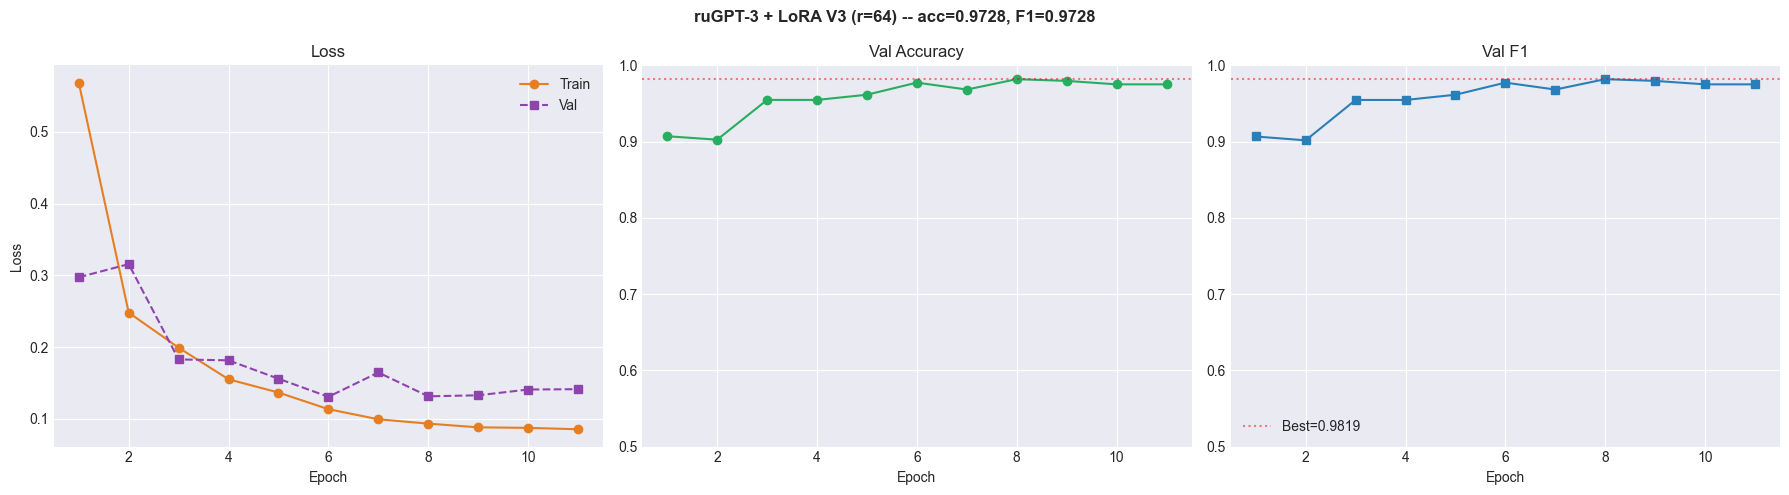

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_x = [h['epoch'] for h in history]

axes[0].plot(epochs_x, [h['train_loss'] for h in history], 'o-', color='#e67e22', label='Train')
axes[0].plot(epochs_x, [h['val_loss'] for h in history], 's--', color='#8e44ad', label='Val')
axes[0].set(title='Loss', xlabel='Epoch', ylabel='Loss')
axes[0].legend()

axes[1].plot(epochs_x, [h['val_acc'] for h in history], 'o-', color='#27ae60')
axes[1].axhline(max(h['val_acc'] for h in history), color='red', ls=':', alpha=0.5)
axes[1].set(title='Val Accuracy', xlabel='Epoch', ylim=(0.5, 1.0))

axes[2].plot(epochs_x, [h['val_f1'] for h in history], 's-', color='#2980b9')
axes[2].axhline(best_f1, color='red', ls=':', alpha=0.5, label=f'Best={best_f1:.4f}')
axes[2].set(title='Val F1', xlabel='Epoch', ylim=(0.5, 1.0))
axes[2].legend()

plt.suptitle(
    f'ruGPT-3 + LoRA V3 (r={LORA_R}) -- acc={test_metrics["accuracy"]:.4f}, F1={test_metrics["f1"]:.4f}',
    fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()


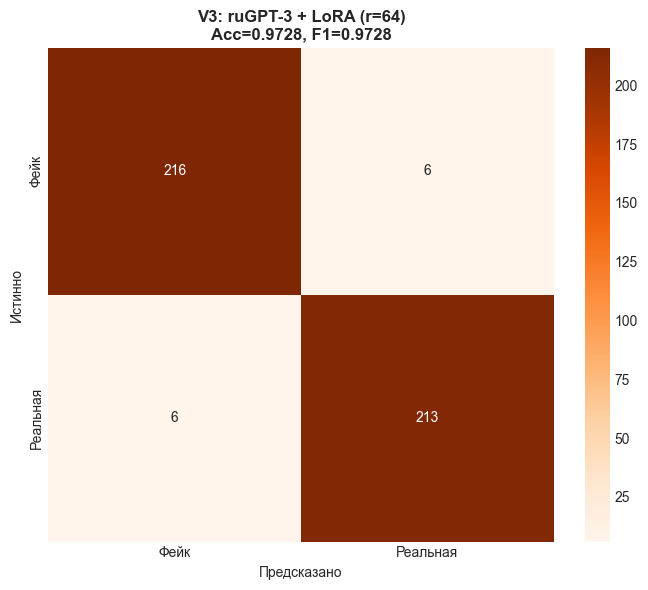

In [11]:
cm = confusion_matrix(test_result['labels'], test_result['preds'])
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Фейк', 'Реальная'],
            yticklabels=['Фейк', 'Реальная'], ax=ax)
ax.set_title(f'V3: ruGPT-3 + LoRA (r={LORA_R})\nAcc={test_metrics["accuracy"]:.4f}, F1={test_metrics["f1"]:.4f}',
             fontweight='bold')
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истинно')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()


## 7. Сравнение со всеми моделями

In [12]:
comparison_data = []

# V1
if os.path.exists('../../models/llm/metrics.json'):
    with open('../../models/llm/metrics.json') as f:
        m = json.load(f)
        v1 = m.get('rugpt3_lora', {})
        if v1:
            comparison_data.append({
                'Model': 'ruGPT-3 + LoRA (V1)', 'Method': 'LLM',
                'Accuracy': v1['accuracy'], 'F1': v1['f1'],
                'Precision': v1['precision'], 'Recall': v1['recall'],
            })

# V2
if os.path.exists('../../models/llm_v2/metrics.json'):
    with open('../../models/llm_v2/metrics.json') as f:
        m = json.load(f)
        e = m.get('ensemble', {})
        if e:
            comparison_data.append({
                'Model': 'Frozen GPT + Sklearn (V2)', 'Method': 'LLM',
                'Accuracy': e['accuracy'], 'F1': e['f1'],
                'Precision': e['precision'], 'Recall': e['recall'],
            })

# RuBERT
if os.path.exists('../../models/rubert/metrics.json'):
    with open('../../models/rubert/metrics.json') as f:
        m = json.load(f)['rubert']
        comparison_data.append({
            'Model': 'RuBERT (fine-tuned)', 'Method': 'Transformer',
            'Accuracy': m['test_acc'], 'F1': m['test_f1'],
            'Precision': m['test_precision'], 'Recall': m['test_recall'],
        })

# TF-IDF
if os.path.exists('../../results/metrics/metrics_tfidf_tuned.json'):
    with open('../../results/metrics/metrics_tfidf_tuned.json') as f:
        m = json.load(f)
        for name, key in [('LR (TF-IDF)', 'logistic_regression'),
                          ('NB (TF-IDF)', 'naive_bayes'),
                          ('RF (TF-IDF)', 'random_forest')]:
            if key in m:
                comparison_data.append({
                    'Model': name, 'Method': 'Classical',
                    'Accuracy': m[key]['val_acc'], 'F1': m[key]['val_f1'],
                    'Precision': m[key].get('precision', 0),
                    'Recall': m[key].get('recall', 0),
                })

# V3 (этот ноутбук)
comparison_data.append({
    'Model': 'ruGPT-3 + LoRA Max (V3)', 'Method': 'LLM (V3)',
    'Accuracy': test_metrics['accuracy'], 'F1': test_metrics['f1'],
    'Precision': test_metrics['precision'], 'Recall': test_metrics['recall'],
})

comparison_df = pd.DataFrame(comparison_data).sort_values('Accuracy', ascending=False).reset_index(drop=True)
comparison_df.index += 1
print(comparison_df.to_string())


                       Model       Method  Accuracy        F1  Precision    Recall
1    ruGPT-3 + LoRA Max (V3)     LLM (V3)  0.972789  0.972789   0.972789  0.972789
2        RuBERT (fine-tuned)  Transformer  0.970522  0.970655   0.959821  0.981735
3                LR (TF-IDF)    Classical  0.960317  0.960301   0.000000  0.000000
4        ruGPT-3 + LoRA (V1)          LLM  0.947846  0.947790   0.949388  0.947846
5                RF (TF-IDF)    Classical  0.941043  0.941042   0.000000  0.000000
6                NB (TF-IDF)    Classical  0.936508  0.936449   0.000000  0.000000
7  Frozen GPT + Sklearn (V2)          LLM  0.897959  0.897938   0.898148  0.897959


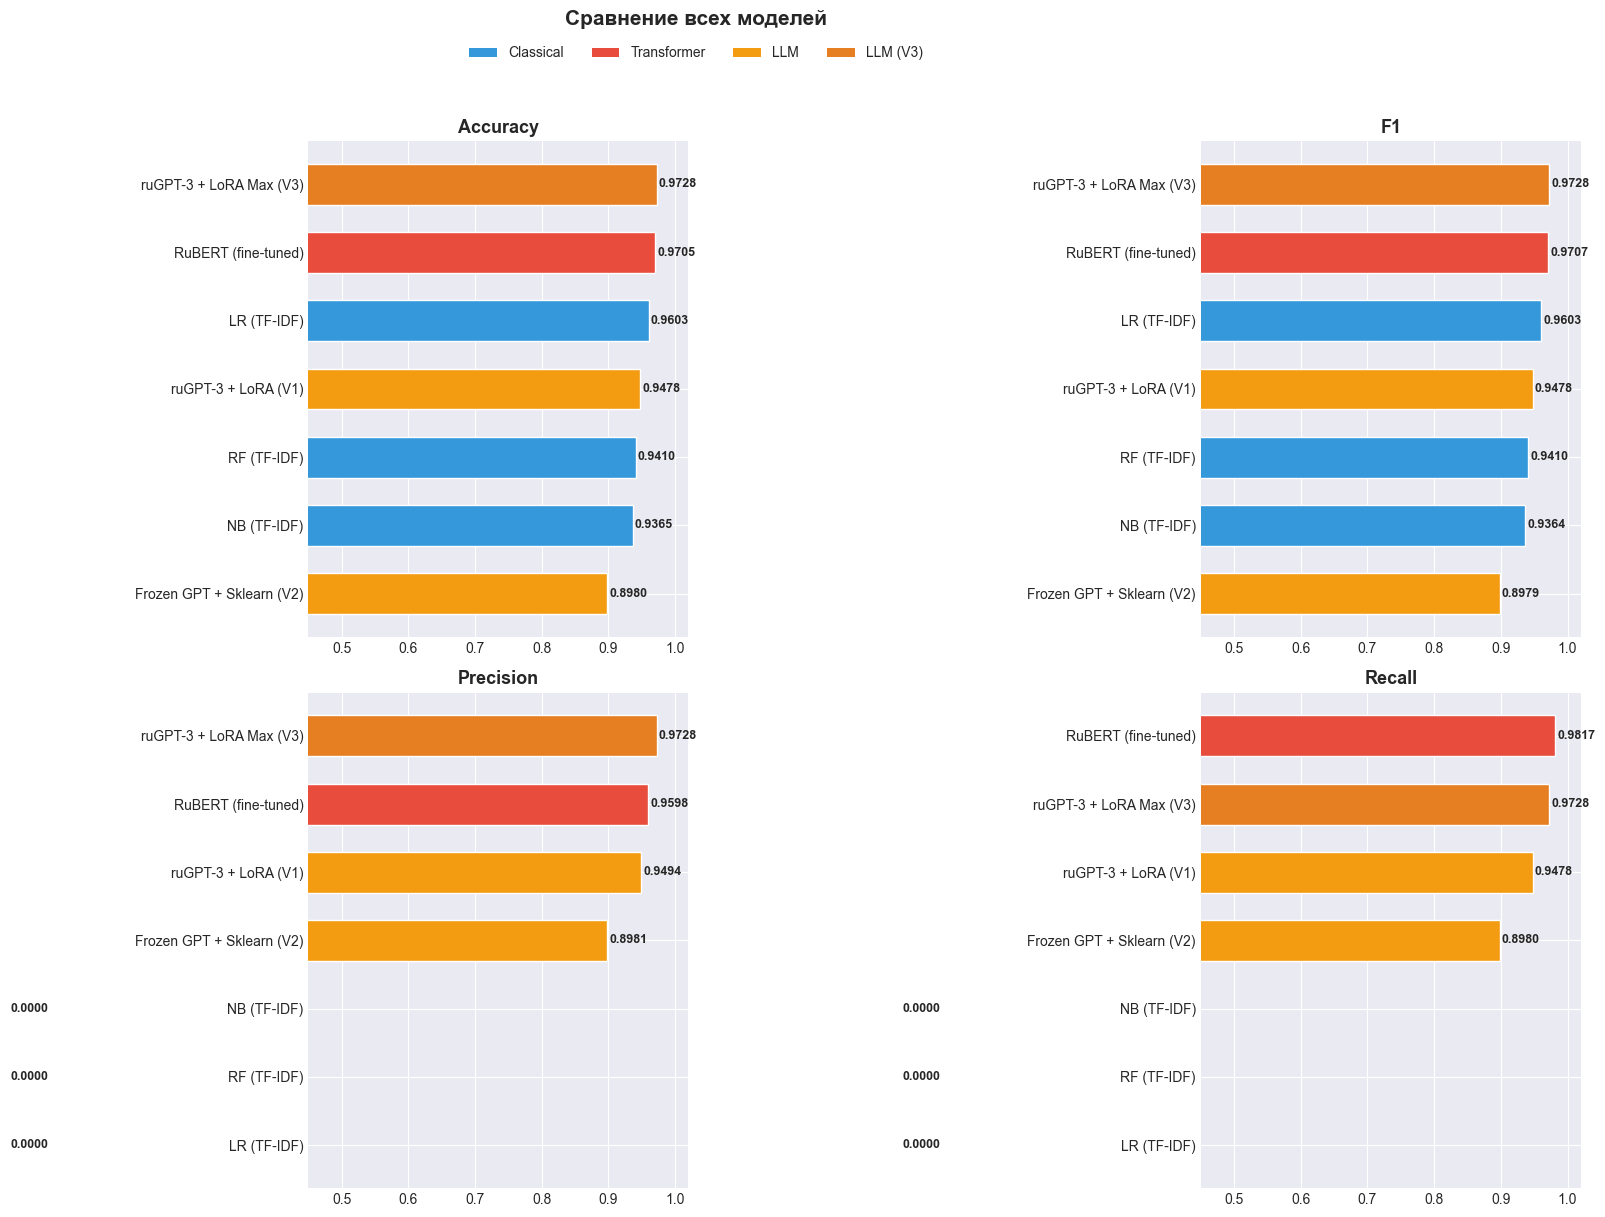

In [13]:
colors_map = {
    'Classical':    '#3498db',
    'Transformer':  '#e74c3c',
    'LLM':          '#f39c12',
    'LLM (V3)':     '#e67e22',
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, metric in [(axes[0,0],'Accuracy'), (axes[0,1],'F1'),
                    (axes[1,0],'Precision'), (axes[1,1],'Recall')]:
    plot_df = comparison_df.sort_values(metric, ascending=True)
    bars = ax.barh(plot_df['Model'], plot_df[metric],
                   color=[colors_map.get(m, '#999') for m in plot_df['Method']],
                   edgecolor='white', height=0.6)
    ax.set_xlim(0.45, 1.02)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    for bar, val in zip(bars, plot_df[metric]):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor=c, label=l) for l, c in colors_map.items()],
           loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.99))
plt.suptitle('Сравнение всех моделей', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('../../assets/complete_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Сохранение

In [14]:
with open(os.path.join(OUTPUT_DIR, 'metrics.json'), 'w', encoding='utf-8') as f:
    json.dump({
        'test': test_metrics,
        'history': history,
        'training_time_min': total_time / 60,
        'config': {
            'model': MODEL_NAME,
            'max_length': MAX_LENGTH,
            'lora_r': LORA_R,
            'lora_alpha': LORA_ALPHA,
            'target_modules': TARGET_MODULES,
            'effective_batch': BATCH_SIZE * GRAD_ACCUM,
            'epochs': EPOCHS,
            'lr': LR,
            'label_smoothing': LABEL_SMOOTH,
        },
    }, f, indent=4, ensure_ascii=False)

pred_df = test_df[[HEADLINE_COL, BODY_COL, LABEL_COL]].copy()
pred_df['pred']      = test_result['preds']
pred_df['prob_real'] = test_result['probs'][:, 1]
pred_df.to_csv(os.path.join(OUTPUT_DIR, 'test_predictions.csv'), index=False)

errors = test_result['preds'] != test_result['labels']
print(f'Верно: {(~errors).sum()}/{len(test_result["labels"])}')
print(f'FP: {((test_result["labels"]==0) & (test_result["preds"]==1)).sum()}')
print(f'FN: {((test_result["labels"]==1) & (test_result["preds"]==0)).sum()}')
print(f'Время обучения: {total_time/3600:.1f}ч')


Верно: 429/441
FP: 6
FN: 6
Время обучения: 21.1ч


## 9. На что смотрит модель

Gradient x Input -- какие токены влияют на предсказание.
Attention heatmap -- как распределяется внимание по слоям.


TypeError: expected Tensor as element 0 in argument 0, but got NoneType

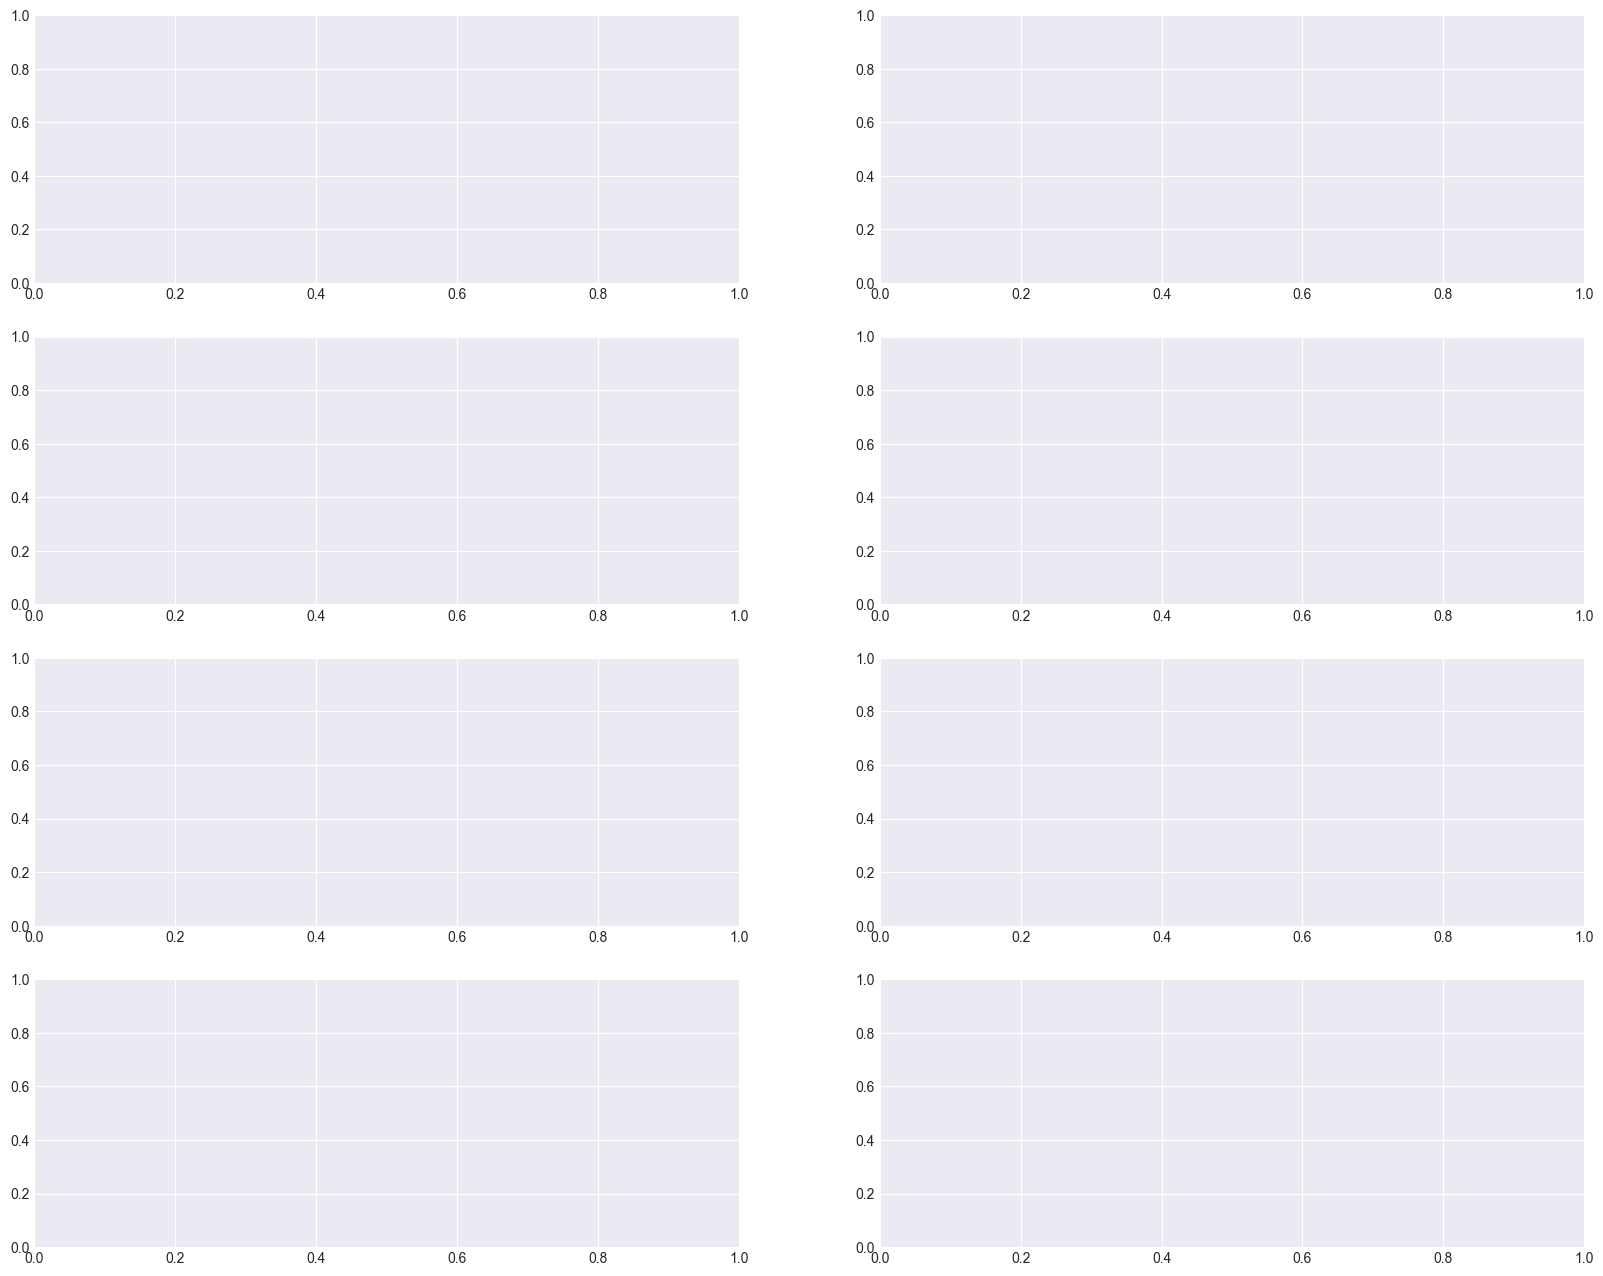

In [16]:
from collections import defaultdict

def get_token_importance(model, tokenizer, text, device='cpu'):
    model.eval()
    enc = tokenizer(text, return_tensors='pt', truncation=True,
                    max_length=MAX_LENGTH, padding='max_length')
    input_ids = enc['input_ids'].to(device)
    attention_mask = enc['attention_mask'].to(device)

    embeddings = model.get_input_embeddings()(input_ids)
    embeddings.requires_grad_(True)
    embeddings.retain_grad()

    outputs = model.base_model.model.transformer(
        inputs_embeds=embeddings, attention_mask=attention_mask, output_attentions=True)
    hidden = outputs.last_hidden_state
    seq_len = attention_mask.sum(dim=-1).long() - 1
    pooled = hidden[0, seq_len[0], :]
    logits = model.base_model.model.score(pooled.unsqueeze(0))
    pred_class = logits.argmax(dim=-1).item()
    prob = torch.softmax(logits, dim=-1)[0]
    logits[0, pred_class].backward()

    grad = embeddings.grad[0]
    importance = (grad * embeddings[0].detach()).norm(dim=-1)
    mask = attention_mask[0].cpu()
    importance = importance.detach().cpu() * mask.float()

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu())
    real_len = int(mask.sum().item())
    tokens = tokens[:real_len]
    importance = importance[:real_len].numpy()

    avg_attn = torch.stack(outputs.attentions).mean(dim=(0, 1, 2))
    avg_attn = avg_attn[:real_len].detach().cpu().numpy()

    return tokens, importance, avg_attn, pred_class, prob.detach().cpu().numpy(), outputs.attentions

# 4 примера: TP fake, TP real, FP, FN

tp_fake = np.where((test_result['preds'] == 0) & (test_result['labels'] == 0))[0]
tp_real = np.where((test_result['preds'] == 1) & (test_result['labels'] == 1))[0]
fp = np.where((test_result['preds'] == 1) & (test_result['labels'] == 0))[0]
fn = np.where((test_result['preds'] == 0) & (test_result['labels'] == 1))[0]

examples = []
for name, idx_arr in [('Верно: фейк', tp_fake), ('Верно: реальная', tp_real),
                       ('FP (фейк->реал)', fp), ('FN (реал->фейк)', fn)]:
    if len(idx_arr) > 0:
        i = idx_arr[0]
        examples.append((name, f"{test_df.iloc[i][HEADLINE_COL]} | {test_df.iloc[i][BODY_COL]}",
                         int(test_df.iloc[i][LABEL_COL])))

fig, axes = plt.subplots(len(examples), 2, figsize=(20, 4 * len(examples)))
if len(examples) == 1:
    axes = axes.reshape(1, -1)

for row, (title, text, true_label) in enumerate(examples):
    tokens, importance, attn, pred, prob, _ = get_token_importance(best_model, tokenizer, text, DEVICE)
    show_n = min(60, len(tokens))
    disp = [t.replace('\u0120', ' ').replace('\u010a', '\\n') for t in tokens[:show_n]]

    ax1 = axes[row, 0]
    c1 = ['#e74c3c' if imp > np.percentile(importance[:show_n], 90) else '#3498db' for imp in importance[:show_n]]
    ax1.bar(range(show_n), importance[:show_n], color=c1, width=0.8)
    ax1.set_xticks(range(show_n))
    ax1.set_xticklabels(disp, rotation=90, fontsize=6)
    ax1.set_title(f'{title} | pred={["фейк","реал"][pred]} ({prob[pred]:.0%})', fontsize=10, fontweight='bold')
    ax1.set_ylabel('Gradient*Input')

    ax2 = axes[row, 1]
    c2 = ['#e67e22' if a > np.percentile(attn[:show_n], 90) else '#27ae60' for a in attn[:show_n]]
    ax2.bar(range(show_n), attn[:show_n], color=c2, width=0.8)
    ax2.set_xticks(range(show_n))
    ax2.set_xticklabels(disp, rotation=90, fontsize=6)
    ax2.set_title(f'{title} | Attention', fontsize=10, fontweight='bold')
    ax2.set_ylabel('Attention')

plt.suptitle('Важность токенов', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(os.path.join(OUTPUT_DIR, 'token_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

# Attention heatmap

fake_idx = np.where(test_result['labels'] == 0)[0][0]
sample_text = f"{test_df.iloc[fake_idx][HEADLINE_COL]} | {test_df.iloc[fake_idx][BODY_COL]}"
enc = tokenizer(sample_text, return_tensors='pt', truncation=True, max_length=MAX_LENGTH, padding=False)
with torch.no_grad():
    outputs = best_model.base_model.model.transformer(
        input_ids=enc['input_ids'].to(DEVICE),
        attention_mask=enc['attention_mask'].to(DEVICE),
        output_attentions=True)

attentions = outputs.attentions
n_layers = len(attentions)
seq_len = enc['input_ids'].shape[1]
toks = tokenizer.convert_ids_to_tokens(enc['input_ids'][0].cpu())
toks = [t.replace('\u0120', ' ').replace('\u010a', '\\n') for t in toks]
show_n = min(40, seq_len)

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
for ax, li in zip(axes.flat, np.linspace(0, n_layers-1, 6, dtype=int)):
    attn_m = attentions[li][0].mean(dim=0).detach().cpu().numpy()[:show_n, :show_n]
    sns.heatmap(attn_m, ax=ax, cmap='YlOrRd', vmin=0,
                xticklabels=toks[:show_n], yticklabels=toks[:show_n], cbar_kws={'shrink': 0.6})
    ax.set_title(f'Layer {li+1}/{n_layers}', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=90, labelsize=5)
    ax.tick_params(axis='y', rotation=0, labelsize=5)

plt.suptitle('Attention по слоям (фейковая новость)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(os.path.join(OUTPUT_DIR, 'attention_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

# Топ-25 слов по классам

word_imp_fake = defaultdict(list)
word_imp_real = defaultdict(list)

for i in tqdm(range(min(50, len(test_df))), desc='Анализ слов'):
    row = test_df.iloc[i]
    text = f"{row[HEADLINE_COL]} | {row[BODY_COL]}"
    try:
        tokens, importance, _, _, _, _ = get_token_importance(best_model, tokenizer, text, DEVICE)
    except Exception:
        continue
    d = word_imp_fake if int(row[LABEL_COL]) == 0 else word_imp_real
    for tok, imp in zip(tokens, importance):
        w = tok.replace('\u0120', '').replace('\u010a', '').strip()
        if len(w) >= 2 and w not in ('|', '||', '--', '..'):
            d[w].append(float(imp))

def top_words(d, n=25):
    avg = {w: np.mean(v) for w, v in d.items() if len(v) >= 2}
    return sorted(avg.items(), key=lambda x: x[1], reverse=True)[:n]

top_f, top_r = top_words(word_imp_fake), top_words(word_imp_real)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
if top_f:
    w, v = zip(*reversed(top_f))
    ax1.barh(range(len(w)), v, color='#e74c3c', height=0.7)
    ax1.set_yticks(range(len(w))); ax1.set_yticklabels(w, fontsize=9)
    ax1.set_title('Фейк: топ-25 слов', fontweight='bold', color='#e74c3c')
if top_r:
    w, v = zip(*reversed(top_r))
    ax2.barh(range(len(w)), v, color='#27ae60', height=0.7)
    ax2.set_yticks(range(len(w))); ax2.set_yticklabels(w, fontsize=9)
    ax2.set_title('Реальные: топ-25 слов', fontweight='bold', color='#27ae60')

plt.suptitle('На какие слова модель смотрит', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(OUTPUT_DIR, 'top_words_by_class.png'), dpi=150, bbox_inches='tight')
plt.show()
